## Project: CNN-based segmentation of cells in multi-modal microscopy images

Contact: Karl Rohr (Heidelberg University K.Rohr@dkfz-heidelberg.de)

### Introduction

Cell segmentation is a central task in biomedical image analysis and enables counting the cell number, quantifying single-cell fluorescence intensity, and tracking of cells to analyze cell motion. Challenges are high variation of cell shape and image intensity, strong image noise, low image contrast, and high cell density. Deep learning methods for cell segmentation in microscopy data show promising results.

### Goal

The goal of this project is to develop a Convolutional Neural Network (CNN) to automatically segment cells in microscopy images. A modified 2D U-Net model (Ronneberger et al., MICCAI 2015, Falk et al., Nature Methods 2019) will be implemented and applied to image data from different imaging modalities comprising fluorescence, differential interference contrast (DIC), and phase-contrast microscopy. Different versions of the network model will be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. The trained models are applied to the different datasets, and the segmentation accuracy will be quantified by a performance metric. The experimental results are analyzed and a comparison of the different network models will be carried out.

### Data and model

The [2D U-Net model](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28) will be used as a basis. Zero-padding (SAME padding) in the convolution layers should be included to ensure that the output size of the network is the same as the input size. This eliminates the need for cropping and resizing of the images in the original model. Experiments with different network configurations should be performed (e.g., different number of layers). Besides using a Cross-Entropy Loss as in the original model, a Dice Loss or a combination of both losses should be investigated. Also, loss weighting as in the original model should be tested. Existing implementations of the U-Net can be used as inspiration.

The network model should be applied to [datasets from the Cell Tracking Challenge](https://celltrackingchallenge.net/2d-datasets/) (Ulman et al., Nature Methods 2017) comprising 2D time-lapse microscopy image data of three different imaging modalities:
1. Fluorescence microscopy: HeLa cells stably expressing H2b-GFP ([download](http://data.celltrackingchallenge.net/training-datasets/Fluo-N2DL-HeLa.zip))
2. Differential interference contrast (DIC) microscopy: HeLa cells on a flat glass ([download](http://data.celltrackingchallenge.net/training-datasets/DIC-C2DH-HeLa.zip))
3. Phase-contrast microscopy: Glioblastoma-astrocytoma U373 cells on a polyacrylamide substrate ([download](http://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip))

Each dataset consists of two image sequences from which single images should be used as samples. The images can be found in the folders `01` and `02`. Since the "gold truth" provided in the folders `01_GT/SEG` and `02_GT/SEG` is not available for all single images or cells, the "silver truth" in `01_ST/SEG` or `02_ST/SEG`can be used. More information on the datasets can be found [here](https://celltrackingchallenge.net/). One of the two image sequences should be used for training and the other for testing. The labels are instance labels (with a different ID for each cell), which need to be converted to semantic labels (foreground-background).

Different versions of the network model should be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. A comparison of the different network models should be performed. The Jaccard Index (Intersection over Union) can be used as segmentation performance metric. A strategy needs to be found to deal with large image sizes (e.g., using image resizing or image tiling as in the original model). To improve the segmentation result, different preprocessing and data augmentation strategies can be studied. Information on deep learning for image segmentation and the U-Net is provided in the lecture (Karl Rohr).


### References
Ronneberger 0, Fischer P, Brox T. (2015) [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28), MICCAI 2015, 234–241

Falk T, Brox T, Ronneberger O et al. (2019) [U-Net: deep learning for cell counting, detection, and morphometry](https://www.nature.com/articles/s41592-018-0261-2), Nature Methods 16, 67-70

Ulman V, Maška M, Harder N, Rohr K, Kozubek M, Ortiz-de-Solorzano C, et al. (2017) [An objective comparison of cell-tracking algorithms](https://www.nature.com/articles/nmeth.4473), Nature Methods 14, 1141–1152




In [22]:
# Install pytorch.lightning
!pip install lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [95]:

# import of necessary libraries
import torch.nn as nn
import torch.nn.functional as F
import os
import random
import torch

import numpy as np
import seaborn as sns
import torch.nn as nn
import lightning.pytorch as pl
import matplotlib.pyplot as plt

from PIL import Image
from typing import List
from torch.utils.data import DataLoader, Dataset

from tqdm.notebook import tqdm
import scipy
from torchvision.transforms import Compose
from skimage.transform import resize
from torchmetrics.segmentation import MeanIoU

In [132]:
DATASET_PATH = "data"
CHECKPOINT_PATH = "models"

TRAIN_DATA = DATASET_PATH + "/DIC-C2DH-HeLa/01"
TRAIN_LABELS = DATASET_PATH + "/DIC-C2DH-HeLa/01_ST"

VAL_DATA = DATASET_PATH + "/DIC-C2DH-HeLa/02"
VAL_LABELS = DATASET_PATH + "/DIC-C2DH-HeLa/02_ST"

In [ ]:
# # Example Training data
# TRAIN_DATA = "DIC-C2DH-HeLa/02"

# # Example Test data
# TEST_DATA = "DIC-C2DH-HeLa/02_ST"

# # Path to the folder where the datasets are/should be downloaded
# DATASET_PATH = "/content/drive"

# # Path to the folder where the pretrained models are saved
# CHECKPOINT_PATH = "./saved_models"

# # Create directory if it doesn't exist
# if not os.path.exists(CHECKPOINT_PATH):
#     os.makedirs(CHECKPOINT_PATH)

In [3]:
# # Get Data
# from google.colab import drive
# drive.mount(DATASET_PATH)

# TRAIN_PATH = os.path.join(DATASET_PATH, 'MyDrive/data', TRAIN_DATA)
# TEST_PATH = os.path.join(DATASET_PATH, 'MyDrive/data', TEST_DATA)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [54]:
seed = 42
def set_seed(seed: int = 42) -> None:
    """ Function setting the seed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(seed)

Seed set to 42


In [5]:
def list_files_in_folder(folder_path: str) -> List[str]:
    """ Function returns a list of paths to
    all files in the given folder.

    :param folder_path: Path to the folder.
    :return: List of file paths.
    """
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

In [6]:
def Train_Unet(train_dataloader,
               epochs,
               model,
               optimizer = None,
               loss_fn = torch.nn.CrossEntropyLoss()):
    model = model
    if optimizer == None:
        optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    for epoch in range(epochs):
        avg_loss = 0
        pbar = tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}")
        for i, data in enumerate(pbar):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            labels = labels.squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)

            loss = loss_fn(outputs, labels)
            loss.backward()

            avg_loss += loss
            pbar.set_postfix(loss=loss.item())

            optimizer.step()
        print(f'End of epoch {epoch + 1}, average loss: {avg_loss / len(train_dataloader)}')
    return model

In [73]:
class TIF_dataset(Dataset):

    def __init__(self,
                 path_list_data,
                 path_list_label,
                 image_transform = None,
                 label_transform = None,
                 dataset_maximum = None,):

        self.path_list_data = path_list_data
        self.path_list_label = path_list_label
        self.image_transform = image_transform
        self.label_transform = label_transform
        self.dataset_maximum = dataset_maximum

    def __len__(self):
        return len(self.path_list_data)

    def __getitem__(self, idx):
        image = Image.open(self.path_list_data[idx])
        image_np = np.array(image).astype('float32')
        label = Image.open(self.path_list_label[idx])
        label_np = np.array(label).astype('float32')
        label_np = np.where(label_np != 0, 1, label_np)
        
        if self.image_transform:
            image_np = self.image_transform(image_np)
            label_np = self.label_transform(label_np)
            
        image_tensor = torch.from_numpy(image_np.copy()).unsqueeze(0).float()
        label_tensor = torch.from_numpy(label_np.copy()).unsqueeze(0).float()            

        if self.dataset_maximum == None:
            image_tensor = (image_tensor - np.mean(image_np))/np.std(image_np) #normalizing the image tensor
        else:
            image_tensor = image_tensor / self.dataset_maximum #normalizing the image tensor

        return image_tensor, label_tensor

In [120]:
def miou(y_true, y_pred):
    intersection = torch.mean((y_true==1).float() * (y_pred==1).float())
    union = torch.mean((y_true==1).float() + (y_pred==1).float()) - intersection
    miou = intersection / union
    return miou

In [116]:
class Convolutional_Block(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size=3,
                 padding=1,
                 stride=1,
                 dropout = 0.1):
        super(Convolutional_Block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm2d(num_features=out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn2 = nn.BatchNorm2d(num_features=out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn3 = nn.BatchNorm2d(num_features=out_channels)
        self.dropout = nn.Dropout(p=dropout, inplace=False)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        residual = x
        x = self.dropout(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout(self.relu(self.bn3(self.conv3(x))))
        x = x + residual
        return x


class UNet(pl.LightningModule):

    def __init__(self,
                 list_of_chanel_numbers,
                 crop = None,
                 loss_fn = torch.nn.CrossEntropyLoss(),
                 lr = 0.001,
                 betas = (0.9, 0.999),
                 kernel_size=3,
                 dropout = 0.1,
                 padding = 1,
                 log = False,
                 len_train = 1,
                 len_val = 1):
        super(UNet, self).__init__()
        self.list_of_chanel_numbers = list_of_chanel_numbers
        self.channel_pairs = [(list_of_chanel_numbers[i], list_of_chanel_numbers[i+1]) for i in range(len(list_of_chanel_numbers) - 1)]
        self.bottom_path = nn.ModuleList()
        self.top_path = nn.ModuleList()
        self.UpConvs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size = 2)
        for pair in self.channel_pairs:
            c_in, c_out = pair
            self.bottom_path.append(Convolutional_Block(c_in, c_out, kernel_size=kernel_size, dropout = dropout, padding = padding))
        self.bottom_block = Convolutional_Block(list_of_chanel_numbers[-1], list_of_chanel_numbers[-1], kernel_size=kernel_size, dropout = dropout, padding=padding)
        self.channel_pairs[0] = (2, list_of_chanel_numbers[1]) # 2 classes
        self.channel_pairs.reverse()
        for pair in self.channel_pairs:
            c_out, c_in = pair
            self.UpConvs.append(torch.nn.ConvTranspose2d(c_in, c_in, kernel_size = 2, stride = 2, ))
            self.top_path.append(Convolutional_Block(c_in, c_out, kernel_size=kernel_size, dropout = dropout, padding=padding))

        self.crop = crop
        self.loss_fn = loss_fn
        self.lr = lr
        self.betas = betas
        self.allow_logging = log
        self.kernel_size = kernel_size
        self.padding = padding
        self.dropout = dropout
        
        self.avg_train_loss = 0
        self.avg_val_loss = 0
        self.val_miou = 0
        self.miou = MeanIoU(num_classes=2)
        self.len_train = len_train
        self.len_val = len_val

    def forward(self, x):
        residuals = []
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)

        residuals.reverse()
        x = self.bottom_block(x)

        for i, module in enumerate(self.top_path):
            if i >= 0:
                x = self.UpConvs[i](x)
            x = x + residuals[i]
            x = module(x)

        return x

    def training_step(self, batch, batch_idx):
        inputs, labels = batch

        if self.crop != None:
            inputs = inputs[:, :, :self.crop, :self.crop]
            labels = labels[:, :, :self.crop, :self.crop]

        labels = labels.squeeze().long()
        outputs = self.forward(inputs)
        loss = self.loss_fn(outputs, labels)

        self.avg_train_loss += loss

        # print(f'TRRAINING: Batch {batch_idx}, loss {loss}')
        if self.allow_logging:
            self.log('Training Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        self.eval()
        with torch.no_grad():
            inputs, labels = batch

            if self.crop != None:
                inputs = inputs[:, :, :self.crop, :self.crop]
                labels = labels[:, :, :self.crop, :self.crop]

            labels = labels.squeeze().long()
            outputs = self.forward(inputs)
            loss = self.loss_fn(outputs, labels)

            self.avg_val_loss += loss
            self.val_miou += miou(outputs.argmax(1), labels)

            # print(f'   VALIDATION: Batch {batch_idx}, loss {loss}')
            if self.allow_logging:
                self.log('Validation Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
                self.log('Validation MIoU', self.val_miou, on_step=True, on_epoch=True, prog_bar=True)
            return loss
        
    def on_validation_end(self):
        print(f'Epoch {self.current_epoch}, Training loss: {self.avg_train_loss/self.len_train}, Validation loss: {self.avg_val_loss/self.len_val}, Validation MIoU: {self.val_miou/self.len_val}')
        self.avg_train_loss = 0
        self.avg_val_loss = 0
        self.val_miou = 0

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr = self.lr, betas = self.betas)

    def generate_numpy_output_from_single_image(self, img):
        model_return_numpy = channel_comparison(img)
        return model_return_numpy

    def run_model_on_validation_dataloder(self, val_dataloader, calculate_pixel_wise_accuracy = False, calculate_tpr = False):
        self.eval()
        with torch.no_grad():
            total_loss = 0
            batches = 0
            total_accuracy = 0
            total_tpr = 0
            for data in val_dataloader:
                batches +=1
                inputs, labels = data
                labels = labels.squeeze().long()
                outputs = self.forward(inputs)
                loss = self.loss_fn(outputs, labels)
                total_loss += loss.item()

                if calculate_pixel_wise_accuracy == True:
                    output_mask = torch.argmax(outputs, dim = 1)
                    accuracy = pixel_wise_accuracy(output_mask, labels)
                    total_accuracy += accuracy

                if calculate_tpr == True:
                    output_mask = torch.argmax(outputs, dim = 1)
                    tpr = true_positive_rate(output_mask, labels.squeeze())
                    total_tpr += tpr

            print('Avarage validation loss per batch: ', total_loss / batches)
            if calculate_pixel_wise_accuracy == True:
                print('Avarage pixel wise accuracy per batch: ', total_accuracy / batches)
            if calculate_tpr == True:
                print('Avarage true positive rate per batch: ', total_tpr / batches)

            return total_loss / batches

In [10]:
def plot_heatmap(data):
    plt.imshow(data, cmap='inferno', interpolation='nearest')
    plt.colorbar()
    plt.show()


def list_files_in_folder(folder_path):
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

def channel_comparison(tensor):
    if tensor.shape != (1, 2, 512, 512):
        raise ValueError("Input tensor must have shape (1, 2, 512, 512)")

    # Extract the first and second channels
    first_channel = tensor[0, 0, :, :]
    second_channel = tensor[0, 1, :, :]

    # Compare the values
    comparison_result = (second_channel > first_channel).numpy().astype(np.uint8)

    return comparison_result

# TO CHANGE
def process_images(image_paths,
                   label_paths,
                   output_folder_image,
                   output_folder_label,
                   k=1):
    if not os.path.exists(output_folder_image):
        raise Exception(f"{output_folder_image} No such file or directory")

    for i in range(len(image_paths)):
        image = Image.open(image_paths[i])
        label = Image.open(label_paths[i])
        image_name = os.path.basename(image_paths[i])
        label_name = os.path.basename(label_paths[i])
        for i in range(k):
            cropped_image, cropped_label = random_crop(image, label, (512, 512))
            rotated_image, rotated_label = random_rotate(cropped_image, cropped_label)
            output_path_image = os.path.join(output_folder_image, f"{os.path.splitext(image_name)[0]}_{i}.tif")
            output_path_label = os.path.join(output_folder_label, f"{os.path.splitext(label_name)[0]}_{i}.tif")
            rotated_image.save(output_path_image, format='TIFF')
            rotated_label.save(output_path_label, format='TIFF')

def random_crop(image, label, size):
    width, height = image.size
    new_width, new_height = size
    if width < new_width or height < new_height:
        raise ValueError("Crop size is larger than the image size.")

    left = random.randint(0, width - new_width)
    top = random.randint(0, height - new_height)
    right = left + new_width
    bottom = top + new_height

    return image.crop((left, top, right, bottom)), label.crop((left, top, right, bottom))

def random_rotate(image, label, fillcolor = 32999, fillcolor_label = 0):
    angle = random.uniform(0, 360)
    return image.rotate(angle, expand=False, fillcolor = fillcolor), label.rotate(angle, expand=False, fillcolor = fillcolor_label)


def plot_results(arr1, arr2, arr3):

    # Setting up the figure and axes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    min_val = min(arr1.min(), arr2.min(), arr3.min())
    max_val = max(arr1.max(), arr2.max(), arr3.max())

    # Creating heatmaps
    sns.heatmap(arr1, ax=axs[0], cbar=False, cmap='viridis')
    axs[0].set_title('Orginal image')
    axs[0].set_xticks([])
    axs[0].set_yticks([])

    sns.heatmap(arr2, ax=axs[1], cbar=False, cmap='viridis', vmin=min_val, vmax=max_val)
    axs[1].set_title('Label')
    axs[1].set_xticks([])
    axs[1].set_yticks([])

    sns.heatmap(arr3, ax=axs[2], cbar=False,cmap='viridis', vmin=min_val, vmax=max_val)
    axs[2].set_title('Model prediction')
    axs[2].set_xticks([])
    axs[2].set_yticks([])

    plt.tight_layout()
    plt.show()

In [134]:
# Architecture
SIZES = [1, 4, 16, 64]

# Example training and testing data
X_train =  list_files_in_folder(TRAIN_DATA)
Y_train =  list_files_in_folder(TRAIN_LABELS)
X_val =  list_files_in_folder(VAL_DATA)
Y_val =  list_files_in_folder(VAL_LABELS)
print("Number of training images found:", len(X_train))
print("Number of testing labels found:", len(Y_train))
print("Number of testing images found:", len(X_val))
print("Number of testing labels found:", len(Y_val))

Number of training images found: 84
Number of testing labels found: 84
Number of testing images found: 84
Number of testing labels found: 84


In [53]:
class RandomRotate90():
    def __init__(self, random_state, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            k = self.random_state.randint(1,4)
            return np.rot90(x,k)
        return x

class RandomContrast():
    def __init__(self, random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = self.random_state.uniform(np.max((0, 1 - self.scale)), 1 + self.scale)
            return np.clip(x * lam, 0, 255)
        return x

class RandomBrightness():
    def __init__(self,random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = 255 * self.scale * self.random_state.uniform(-1,1)
            return np.clip(x + lam, 0, 255)
        return x
    
class RandomElasticDeformation():
    def __init__(self, random_state, grid_size, sigma, order, execution_probability=0.0):
        self.random_state = random_state
        self.grid_size = grid_size
        self.sigma = sigma
        self.order = order
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            h,w = x.shape
            
            dx = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma
            dy = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma

            dx = resize(dx, x.shape, preserve_range=True, order = 3)
            dy = resize(dy, x.shape, preserve_range=True, order = 3)

            idx_x, idx_y = np.meshgrid(np.arange(h), np.arange(w))

            coordinates = idx_y + dy, idx_x + dx

            return scipy.ndimage.map_coordinates(x, coordinates, order = self.order, mode = "reflect", prefilter=False)
        return x


In [ ]:
execution_probability = 0.1
image_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(seed), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(seed), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    RandomContrast(random_state=np.random.RandomState(seed), scale=0.1, execution_probability=execution_probability),
    RandomBrightness(random_state=np.random.RandomState(seed), scale=0.1, execution_probability=execution_probability)
])
label_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(seed), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(seed), grid_size=3, sigma=10, order=1, execution_probability=execution_probability),
])

In [137]:
train_dataset = TIF_dataset(X_train, Y_train, image_transforms_train, label_transforms_train)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=7)
val_dataset = TIF_dataset(X_val, Y_val)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=7)
model = UNet(SIZES, log=True, len_train=len(train_dataloader), len_val=len(val_dataloader)).to(device)
trainer = pl.Trainer(max_epochs=64, log_every_n_steps=1)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [138]:
trainer.fit(model, train_dataloader, val_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type                | Params | Mode 
-------------------------------------------------------------
0 | bottom_path  | ModuleList          | 89.2 K | train
1 | top_path     | ModuleList          | 15.0 K | train
2 | UpConvs      | ModuleList          | 17.6 K | train
3 | pool         | MaxPool2d           | 0      | train
4 | bottom_block | Convolutional_Block | 111 K  | train
5 | loss_fn      | CrossEntropyLoss    | 0      | eval 
6 | miou         | MeanIoU             | 0      | train
-------------------------------------------------------------
232 K     Trainable params
0         Non-trainable params
232 K     Total params
0.932     Total estimated model params size (MB)
71        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Training loss: 0.0, Validation loss: 0.4713621139526367, Validation MIoU: 0.23900103569030762


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 62, Training loss: 0.12329991906881332, Validation loss: 0.27374589443206787, Validation MIoU: 0.8115215301513672


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=64` reached.


Epoch 63, Training loss: 0.12530635297298431, Validation loss: 0.29414939880371094, Validation MIoU: 0.7933944463729858


Model output


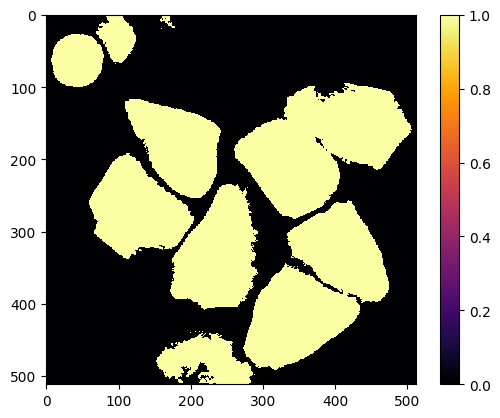

Label


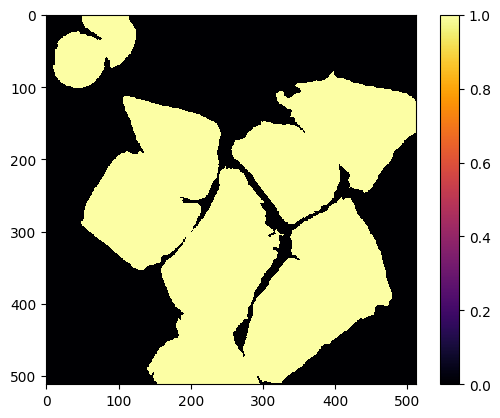

original image


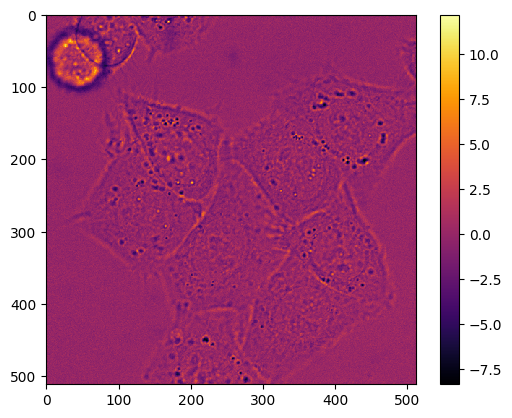

In [140]:
data, label = val_dataset[26]
model.eval()
model.to(device)
output = model(data.unsqueeze(dim = 0).to(device))
model_output = model.generate_numpy_output_from_single_image(output.detach().cpu())

print('Model output')
plot_heatmap(model_output)

print('Label')
plot_heatmap(label.squeeze().numpy())

print('original image')
plot_heatmap(data.squeeze().numpy())